# Geographic density heatmap by area and crime type

C:\Users\bjorn\AppData\Local\Temp\ipykernel_10284\3674404309.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


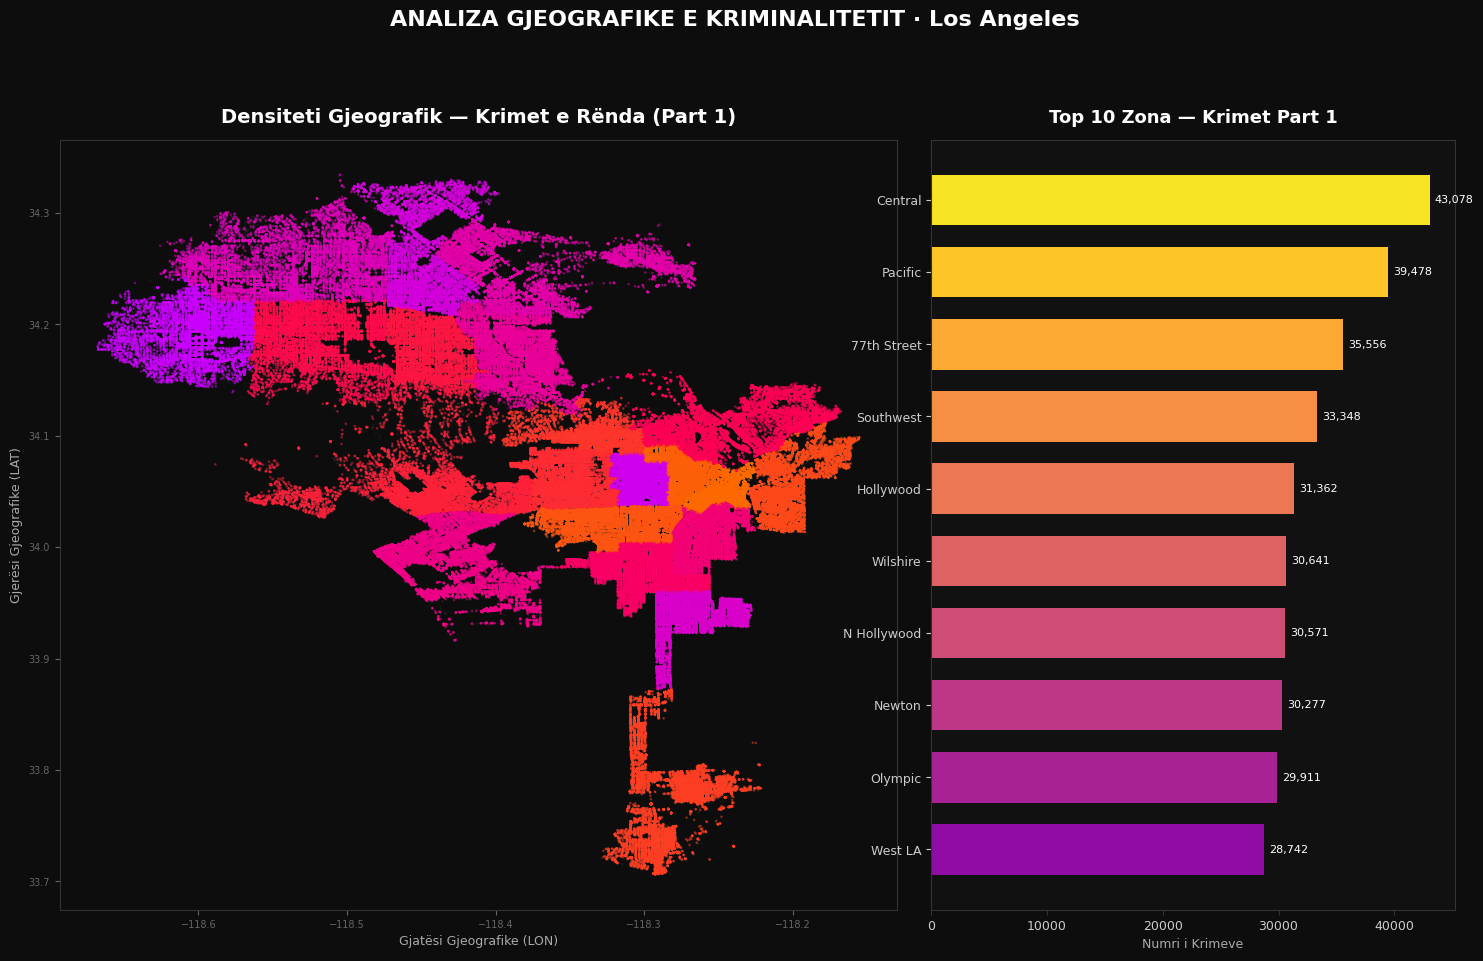

✓ Ruajtur: q1_geo_density.png


In [2]:
"""
Q1: Si ndryshon densiteti gjeografik i krimeve sipas zonës dhe llojit,
    dhe cilat zona kanë përqendrimin më të lartë të krimeve të rënda (Part 1)?
Kolonat: LAT, LON, AREA NAME, Crm Cd Desc, Part 1-2
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------------------
# 1. NGARKO DATASET  (ndrysho rrugën sipas nevojës)
# -------------------------------------------------------------------
df = pd.read_csv("Crime_Data_Filtered.csv", low_memory=False)

# Pastrim bazik
df = df.dropna(subset=["LAT", "LON", "AREA NAME", "Part 1-2"])
df = df[(df["LAT"] != 0) & (df["LON"] != 0)]
df["Part 1-2"] = pd.to_numeric(df["Part 1-2"], errors="coerce")

part1 = df[df["Part 1-2"] == 1]

# -------------------------------------------------------------------
# 2. VIZUALIZIM
# -------------------------------------------------------------------
fig = plt.figure(figsize=(18, 10), facecolor="#0d0d0d")
gs = gridspec.GridSpec(1, 2, width_ratios=[1.6, 1], wspace=0.05)

# --- Panel majtas: scatter harta ---
ax_map = fig.add_subplot(gs[0])
ax_map.set_facecolor("#0d0d0d")

# Të gjitha krimet (background)
ax_map.scatter(df["LON"], df["LAT"], s=0.3, alpha=0.15, color="#444444", rasterized=True)

# Krimet Part 1 me ngjyrë
cmap_fire = LinearSegmentedColormap.from_list("fire", ["#ff6b00", "#ff0055", "#cc00ff"])
sc = ax_map.scatter(
    part1["LON"], part1["LAT"],
    s=0.8, alpha=0.4,
    c=part1["AREA"].astype("category").cat.codes,
    cmap=cmap_fire, rasterized=True
)

ax_map.set_title("Densiteti Gjeografik — Krimet e Rënda (Part 1)",
                 color="white", fontsize=14, fontweight="bold", pad=12)
ax_map.set_xlabel("Gjatësi Gjeografike (LON)", color="#aaaaaa", fontsize=9)
ax_map.set_ylabel("Gjerësi Gjeografike (LAT)", color="#aaaaaa", fontsize=9)
ax_map.tick_params(colors="#666666", labelsize=7)
for spine in ax_map.spines.values():
    spine.set_edgecolor("#333333")

# --- Panel djathtas: top 10 zona me krimet e rënda ---
ax_bar = fig.add_subplot(gs[1])
ax_bar.set_facecolor("#111111")

top_areas = (
    part1.groupby("AREA NAME").size()
    .sort_values(ascending=True)
    .tail(10)
)

colors_bar = plt.cm.plasma(np.linspace(0.3, 0.95, len(top_areas)))
bars = ax_bar.barh(top_areas.index, top_areas.values,
                   color=colors_bar, edgecolor="none", height=0.7)

for bar, val in zip(bars, top_areas.values):
    ax_bar.text(val + top_areas.values.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", ha="left", color="white", fontsize=8)

ax_bar.set_title("Top 10 Zona — Krimet Part 1",
                 color="white", fontsize=13, fontweight="bold", pad=12)
ax_bar.set_xlabel("Numri i Krimeve", color="#aaaaaa", fontsize=9)
ax_bar.tick_params(colors="#cccccc", labelsize=9)
ax_bar.set_facecolor("#111111")
for spine in ax_bar.spines.values():
    spine.set_edgecolor("#333333")
ax_bar.xaxis.set_tick_params(color="#333333")

plt.suptitle("ANALIZA GJEOGRAFIKE E KRIMINALITETIT · Los Angeles",
             color="white", fontsize=16, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("q1_geo_density.png", dpi=150, bbox_inches="tight",
            facecolor="#0d0d0d")
plt.show()
print("✓ Ruajtur: q1_geo_density.png")

# Q2: Profili demografik i viktimave (moshë, gjini, prejardhje) për 5 llojet më të shpeshta të krimeve.
Kolonat: Vict Age, Vict Sex, Vict Descent, Crm Cd Desc

KeyboardInterrupt: 

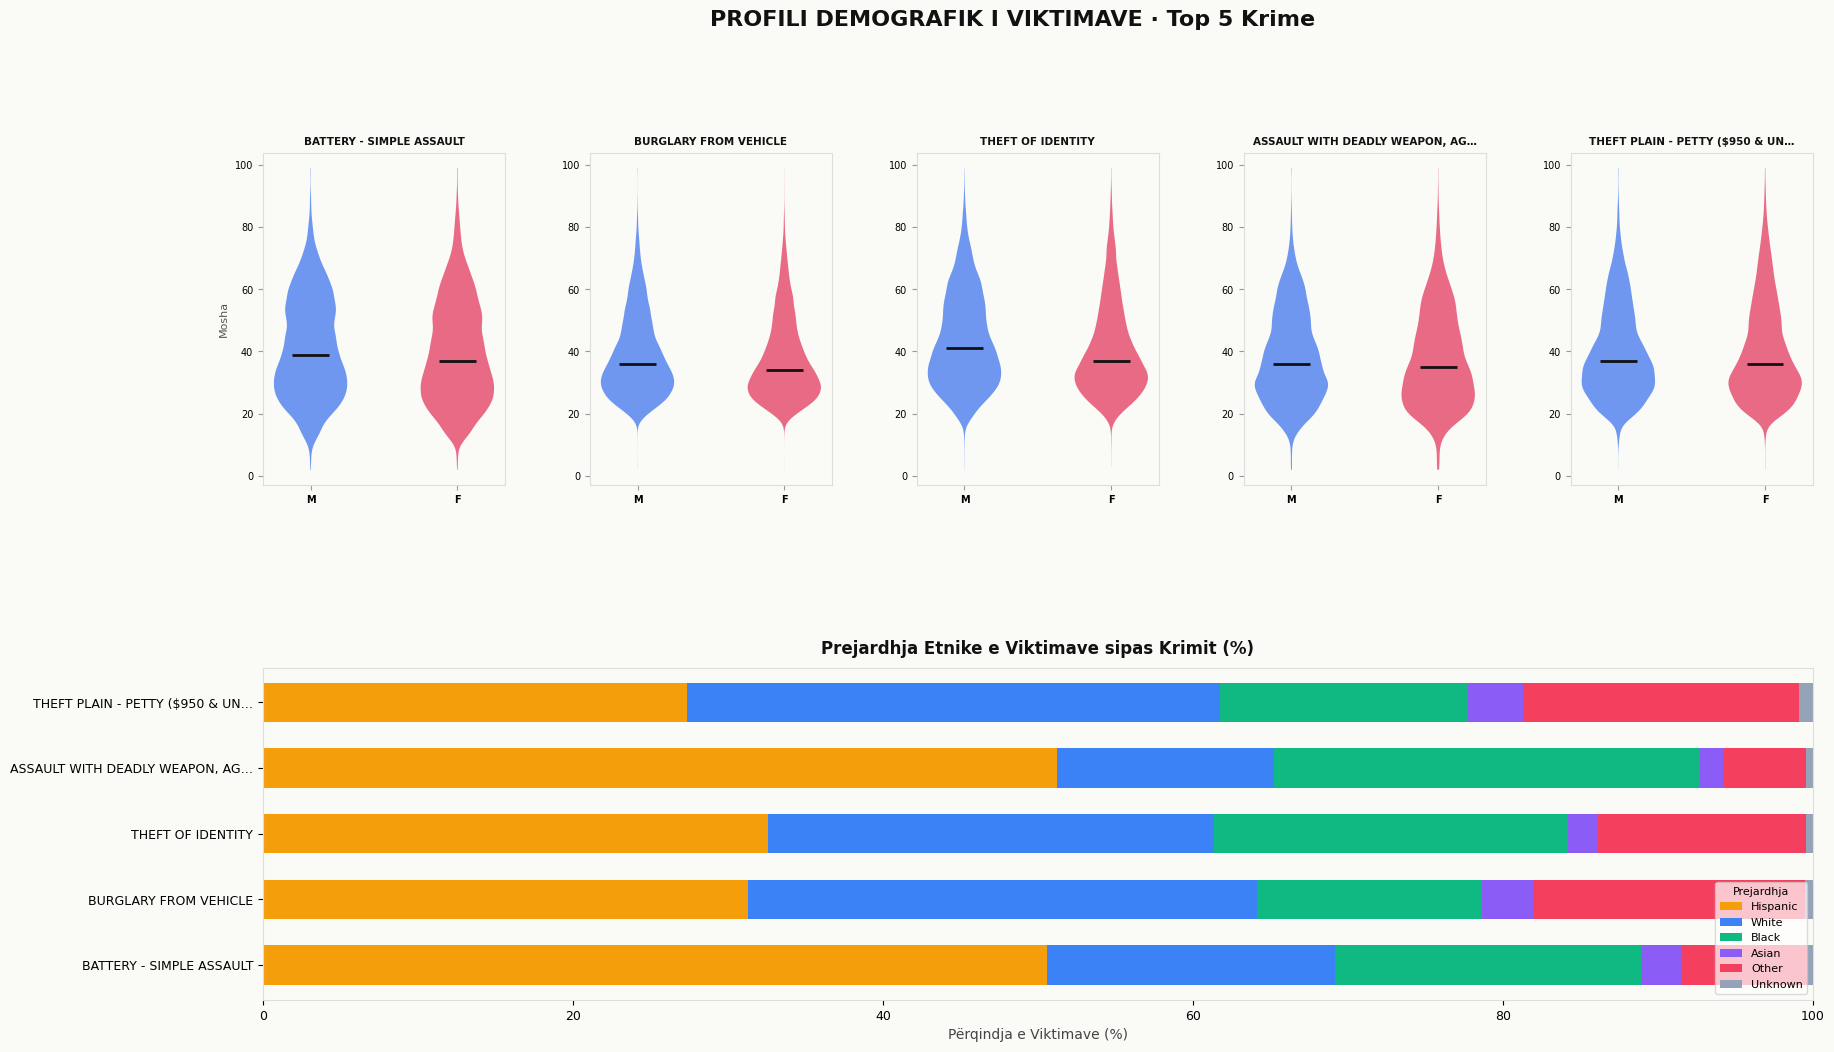

In [5]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# -------------------------------------------------------------------
# 1. NGARKO & PASTRO
# -------------------------------------------------------------------
df = pd.read_csv("Crime_Data_Filtered.csv", low_memory=False)

df = df.dropna(subset=["Vict Age", "Vict Sex", "Vict Descent", "Crm Cd Desc"])
df["Vict Age"] = pd.to_numeric(df["Vict Age"], errors="coerce")
df = df[(df["Vict Age"] > 0) & (df["Vict Age"] < 100)]

# Filtro gjini të njohur
df = df[df["Vict Sex"].isin(["M", "F"])]

# Top 5 krime
top5 = df["Crm Cd Desc"].value_counts().head(5).index.tolist()
df5 = df[df["Crm Cd Desc"].isin(top5)].copy()

# Emra të shkurtër
short_names = {n: n[:30] + ("…" if len(n) > 30 else "") for n in top5}
df5["Crime_Short"] = df5["Crm Cd Desc"].map(short_names)

# Descent map
descent_map = {
    "H": "Hispanic", "W": "White", "B": "Black",
    "A": "Asian", "O": "Other", "X": "Unknown"
}
df5["Descent_Label"] = df5["Vict Descent"].map(descent_map).fillna("Other")

# -------------------------------------------------------------------
# 2. VIZUALIZIM
# -------------------------------------------------------------------
BG = "#fafaf7"
ACCENT_M = "#2563eb"
ACCENT_F = "#e11d48"

fig = plt.figure(figsize=(20, 11), facecolor=BG)
gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.55, wspace=0.35)

# ---- Rreshti 1: violin moshe për secilin krim ----
for i, crime in enumerate(top5):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(BG)

    sub = df5[df5["Crm Cd Desc"] == crime]
    data_m = sub[sub["Vict Sex"] == "M"]["Vict Age"].dropna().values
    data_f = sub[sub["Vict Sex"] == "F"]["Vict Age"].dropna().values

    positions = [1, 2]
    vp = ax.violinplot([data_m, data_f], positions=positions,
                       showmedians=True, showextrema=False)

    for j, (body, color) in enumerate(zip(vp["bodies"], [ACCENT_M, ACCENT_F])):
        body.set_facecolor(color)
        body.set_alpha(0.65)
        body.set_edgecolor("none")
    vp["cmedians"].set_color("#111111")
    vp["cmedians"].set_linewidth(2)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["M", "F"], fontsize=10, fontweight="bold")
    ax.set_ylabel("Mosha" if i == 0 else "", fontsize=8, color="#555")
    ax.set_title(short_names[crime], fontsize=7.5, fontweight="bold",
                 color="#111", wrap=True)
    ax.tick_params(labelsize=7, color="#999")
    for spine in ax.spines.values():
        spine.set_edgecolor("#dddddd")

# ---- Rreshti 2: prejardhja e viktimave (stacked 100%) ----
ax_desc = fig.add_subplot(gs[1, :])
ax_desc.set_facecolor(BG)

descents = ["Hispanic", "White", "Black", "Asian", "Other", "Unknown"]
palette = ["#f59e0b", "#3b82f6", "#10b981", "#8b5cf6", "#f43f5e", "#94a3b8"]

pivot = (
    df5.groupby(["Crime_Short", "Descent_Label"])
    .size().unstack(fill_value=0)
    .reindex(columns=descents, fill_value=0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(pivot_pct))
short_crimes = [short_names[c] for c in top5]

for desc, color in zip(descents, palette):
    if desc in pivot_pct.columns:
        vals = pivot_pct.reindex([short_names[c] for c in top5])[desc].values
        bars = ax_desc.barh(short_crimes, vals, left=bottom,
                            color=color, label=desc, height=0.6)
        bottom += vals

ax_desc.set_xlim(0, 100)
ax_desc.set_xlabel("Përqindja e Viktimave (%)", fontsize=10, color="#444")
ax_desc.set_title("Prejardhja Etnike e Viktimave sipas Krimit (%)",
                  fontsize=12, fontweight="bold", color="#111", pad=10)
ax_desc.tick_params(labelsize=9)
ax_desc.legend(loc="lower right", fontsize=8, framealpha=0.7,
               title="Prejardhja", title_fontsize=8)
for spine in ax_desc.spines.values():
    spine.set_edgecolor("#dddddd")

fig.suptitle("PROFILI DEMOGRAFIK I VIKTIMAVE · Top 5 Krime",
             fontsize=16, fontweight="bold", color="#111", y=1.01)

plt.savefig("q2_victim_demographics.png", dpi=150, bbox_inches="tight",
            facecolor=BG)
plt.show()
print("✓ Ruajtur: q2_victim_demographics.png")

# Q3: Shpërndarja kohore e krimeve (TIME OCC) sipas llojit të vendndodhjes (Premis Desc) dhe kategorisë (Part 1-2).
Kolonat: TIME OCC, Premis Desc, Part 1-2, Crm Cd Desc


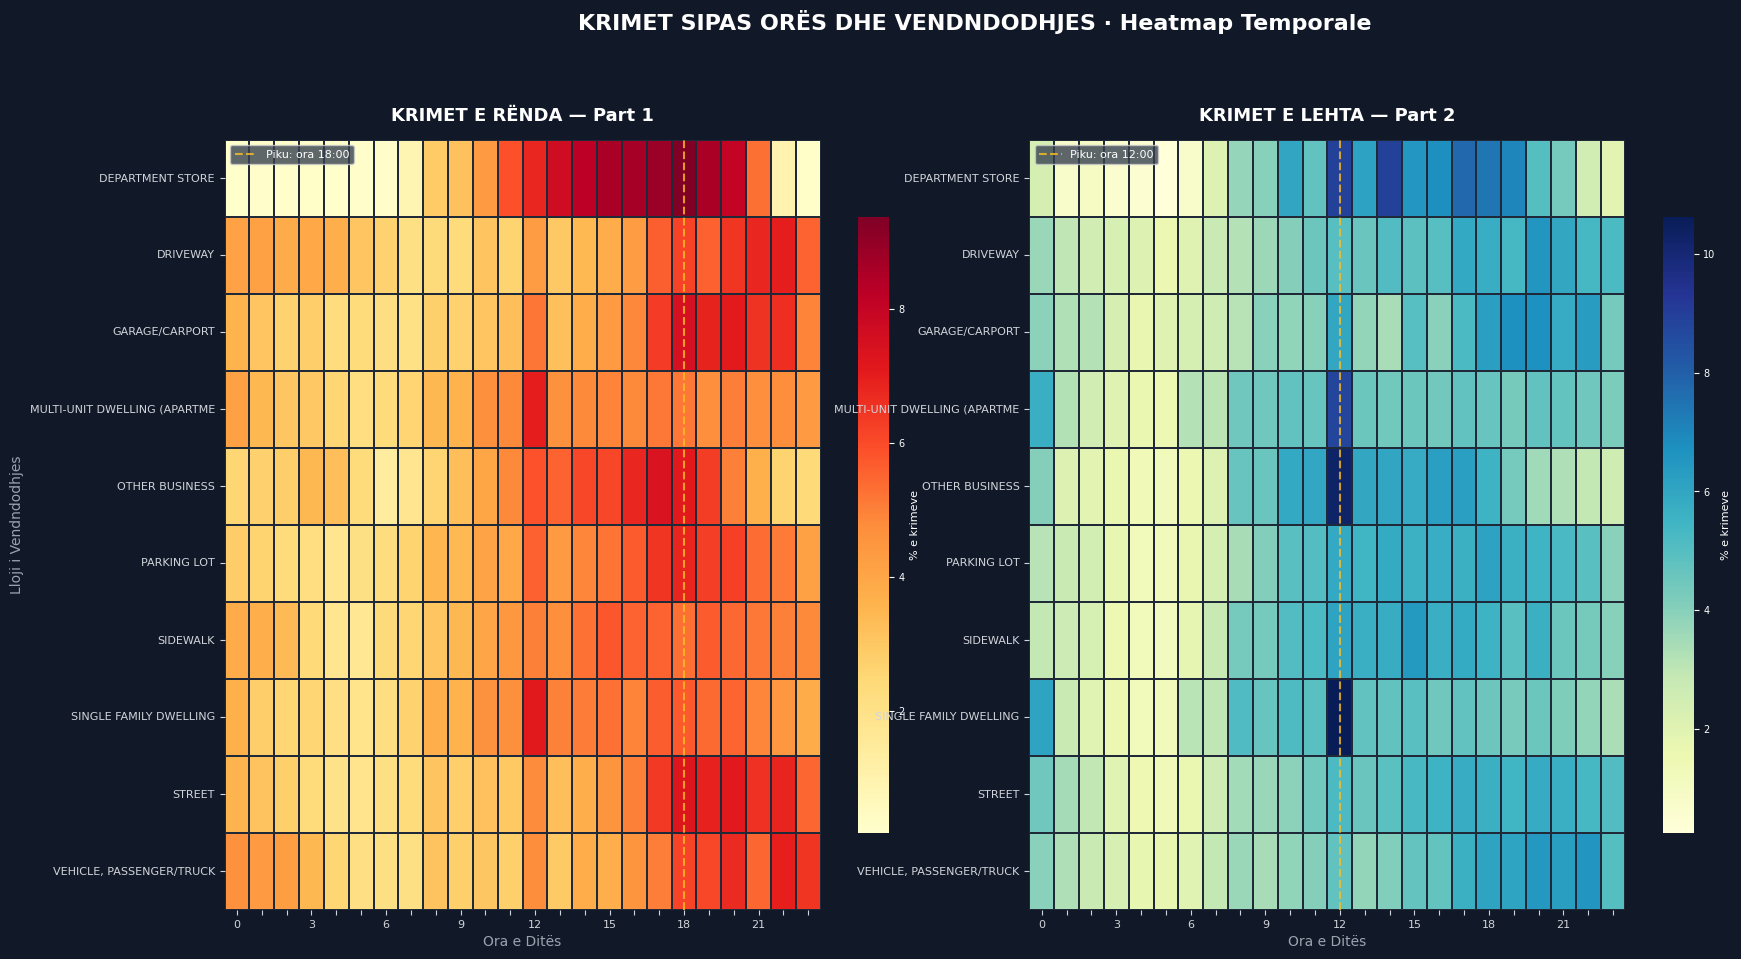

✓ Ruajtur: q3_time_premises_heatmap.png


In [6]:


import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import seaborn as sns

# -------------------------------------------------------------------
# 1. NGARKO & PASTRO
# -------------------------------------------------------------------
df = pd.read_csv("Crime_Data_Filtered.csv", low_memory=False)

df = df.dropna(subset=["TIME OCC", "Premis Desc", "Part 1-2"])
df["TIME OCC"] = pd.to_numeric(df["TIME OCC"], errors="coerce")
df["Part 1-2"] = pd.to_numeric(df["Part 1-2"], errors="coerce")
df = df.dropna(subset=["TIME OCC", "Part 1-2"])

# Orët 0-23
df["Hour"] = (df["TIME OCC"] // 100).astype(int).clip(0, 23)

# Top 10 premise
top_premis = df["Premis Desc"].value_counts().head(10).index.tolist()
df_top = df[df["Premis Desc"].isin(top_premis)].copy()
df_top["Premis_Short"] = df_top["Premis Desc"].str[:28]

# -------------------------------------------------------------------
# 2. BUILD PIVOT  (normalizuar për 100k krime)
# -------------------------------------------------------------------
def make_pivot(data):
    piv = data.groupby(["Premis_Short", "Hour"]).size().unstack(fill_value=0)
    piv = piv.reindex(columns=range(24), fill_value=0)
    # Normalizim rreshtor (% brenda çdo premise)
    piv_norm = piv.div(piv.sum(axis=1), axis=0) * 100
    return piv_norm

part1_piv = make_pivot(df_top[df_top["Part 1-2"] == 1])
part2_piv = make_pivot(df_top[df_top["Part 1-2"] == 2])

# Unify index
all_idx = sorted(set(part1_piv.index) | set(part2_piv.index))
part1_piv = part1_piv.reindex(all_idx, fill_value=0)
part2_piv = part2_piv.reindex(all_idx, fill_value=0)

# -------------------------------------------------------------------
# 3. VIZUALIZIM
# -------------------------------------------------------------------
fig = plt.figure(figsize=(20, 10), facecolor="#111827")
gs = gridspec.GridSpec(1, 2, wspace=0.08)

hour_labels = [f"{h:02d}:00" for h in range(24)]

for ax_i, (piv, title, cmap_name) in enumerate([
    (part1_piv, "KRIMET E RËNDA — Part 1", "YlOrRd"),
    (part2_piv, "KRIMET E LEHTA — Part 2", "YlGnBu"),
]):
    ax = fig.add_subplot(gs[ax_i])
    sns.heatmap(
        piv, ax=ax,
        cmap=cmap_name,
        linewidths=0.3, linecolor="#1f2937",
        cbar_kws={"label": "% e krimeve (brenda premises)", "shrink": 0.8},
        fmt=".0f", annot=False,
        xticklabels=[str(h) if h % 3 == 0 else "" for h in range(24)],
    )
    ax.set_title(title, color="white", fontsize=13, fontweight="bold", pad=14)
    ax.set_xlabel("Ora e Ditës", color="#9ca3af", fontsize=10)
    ax.set_ylabel("Lloji i Vendndodhjes" if ax_i == 0 else "", color="#9ca3af", fontsize=10)
    ax.tick_params(colors="#d1d5db", labelsize=8)
    ax.set_facecolor("#1f2937")

    # Shënon orën e pikut
    peak_hour = piv.mean().idxmax()
    ax.axvline(peak_hour + 0.5, color="#fbbf24", linewidth=1.5,
               linestyle="--", alpha=0.8, label=f"Piku: ora {peak_hour:02d}:00")
    ax.legend(loc="upper left", fontsize=8, facecolor="#374151",
              labelcolor="white", framealpha=0.8)

    # Colorbar styling
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white", fontsize=7)
    cbar.set_label("% e krimeve", color="white", fontsize=8)

fig.suptitle("KRIMET SIPAS ORËS DHE VENDNDODHJES · Heatmap Temporale",
             color="white", fontsize=16, fontweight="bold", y=1.01)

plt.savefig("q3_time_premises_heatmap.png", dpi=150, bbox_inches="tight",
            facecolor="#111827")
plt.show()
print("✓ Ruajtur: q3_time_premises_heatmap.png")

# Q4: Armët më të shpeshta sipas llojit të krimit dhe statusi i zgjidhjes.
Kolonat: Weapon Desc, Crm Cd Desc, Status Desc, Part 1-2

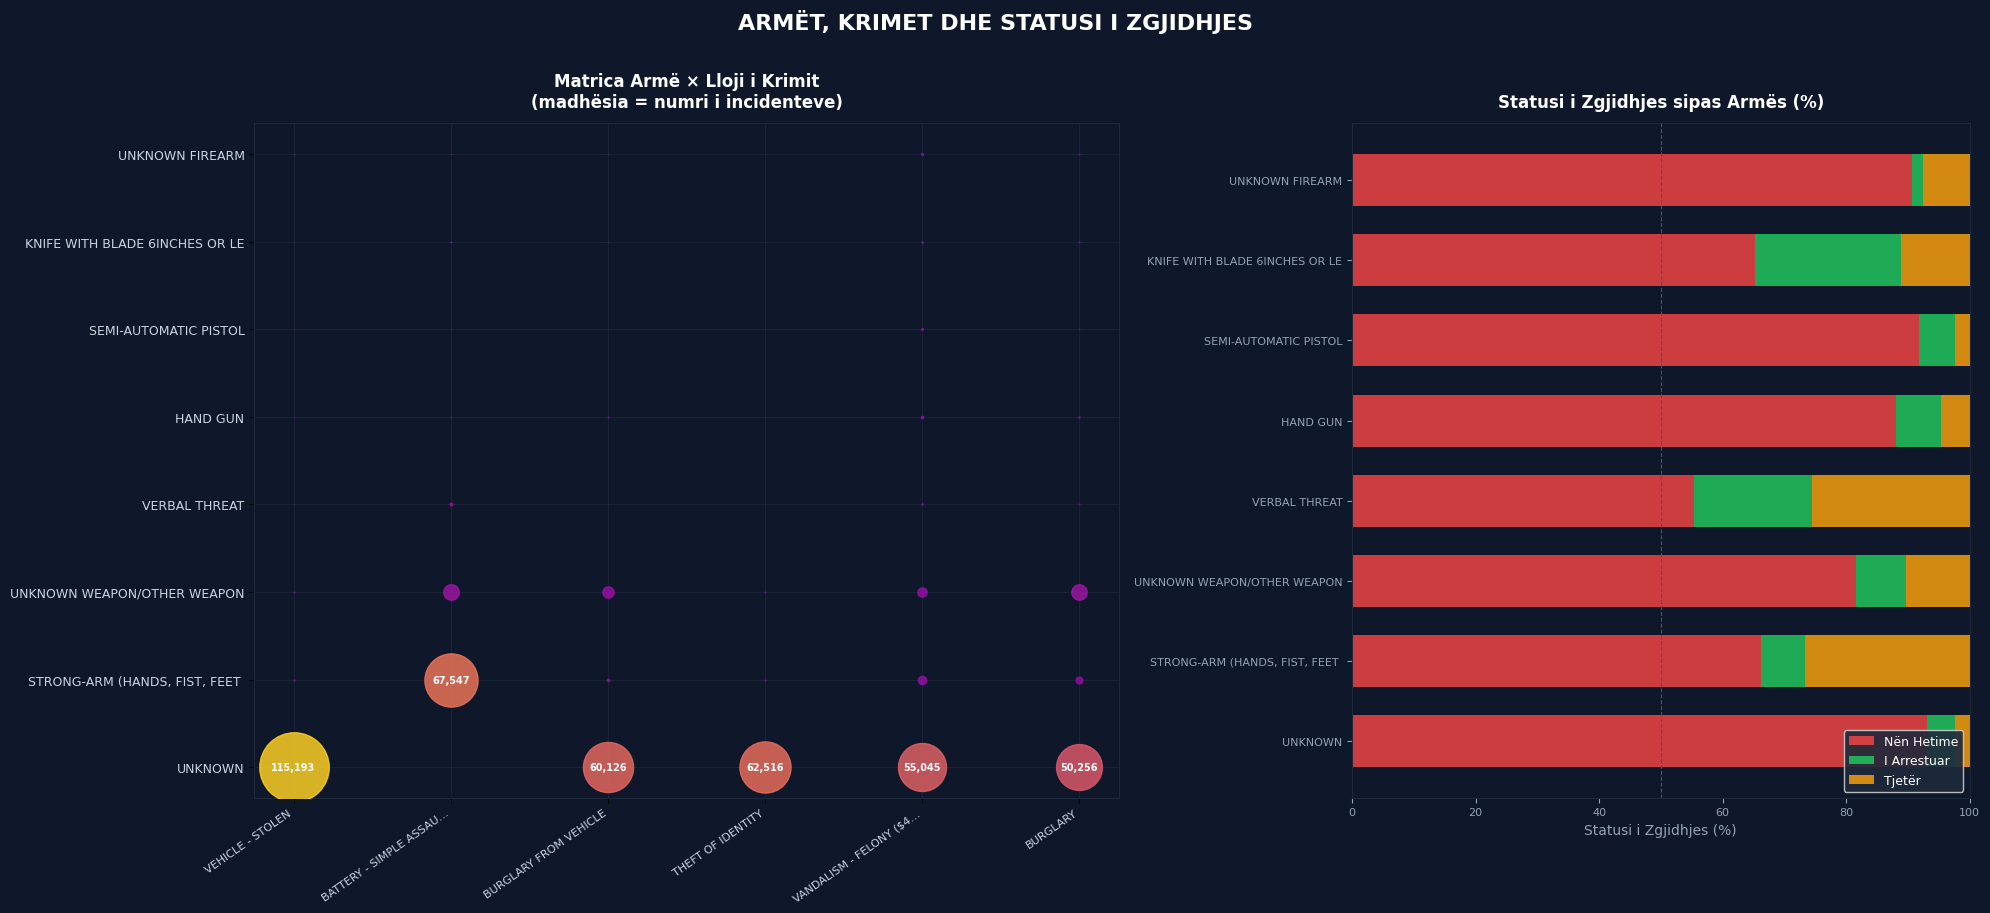

✓ Ruajtur: q4_weapons_crime_status.png


In [7]:


import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# -------------------------------------------------------------------
# 1. NGARKO & PASTRO
# -------------------------------------------------------------------
df = pd.read_csv("Crime_Data_Filtered.csv", low_memory=False)

df = df.dropna(subset=["Weapon Desc", "Crm Cd Desc", "Status Desc"])
df = df[df["Weapon Desc"].str.strip() != ""]

# Top 8 armë & top 6 krime
top_weapons = df["Weapon Desc"].value_counts().head(8).index.tolist()
top_crimes  = df["Crm Cd Desc"].value_counts().head(6).index.tolist()

df_f = df[df["Weapon Desc"].isin(top_weapons) &
          df["Crm Cd Desc"].isin(top_crimes)].copy()

# Statusi i thjeshtëzuar
def simplify_status(s):
    s = str(s).upper()
    if "INVEST" in s or "CONT" in s:   return "Nën Hetime"
    if "ARREST" in s:                   return "I Arrestuar"
    if "JUVEN" in s:                    return "I Arrestuar"
    return "Tjetër"

df_f["Status_Simple"] = df_f["Status Desc"].apply(simplify_status)

status_colors = {"Nën Hetime": "#ef4444", "I Arrestuar": "#22c55e", "Tjetër": "#f59e0b"}

# -------------------------------------------------------------------
# 2. VIZUALIZIM: grouped stacked bar
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 9), facecolor="#0f172a",
                         gridspec_kw={"width_ratios": [1.4, 1]})
fig.patch.set_facecolor("#0f172a")

# --- Panel 1: Armë × Krim (bubble matrix) ---
ax = axes[0]
ax.set_facecolor("#0f172a")

pivot_count = (df_f.groupby(["Weapon Desc", "Crm Cd Desc"])
               .size().unstack(fill_value=0))
pivot_count = pivot_count.reindex(index=top_weapons,
                                  columns=top_crimes, fill_value=0)

max_val = pivot_count.values.max()
for i, weapon in enumerate(top_weapons):
    for j, crime in enumerate(top_crimes):
        val = pivot_count.loc[weapon, crime]
        if val > 0:
            size = (val / max_val) * 2500
            color_intensity = val / max_val
            color = plt.cm.plasma(0.3 + color_intensity * 0.6)
            ax.scatter(j, i, s=size, color=color, alpha=0.85, zorder=3)
            if val > max_val * 0.1:
                ax.text(j, i, f"{val:,}", ha="center", va="center",
                        fontsize=7, color="white", fontweight="bold")

ax.set_xticks(range(len(top_crimes)))
ax.set_xticklabels([c[:22] + "…" if len(c) > 22 else c for c in top_crimes],
                   rotation=35, ha="right", color="#cbd5e1", fontsize=8)
ax.set_yticks(range(len(top_weapons)))
ax.set_yticklabels([w[:30] for w in top_weapons], color="#cbd5e1", fontsize=9)
ax.set_title("Matrica Armë × Lloji i Krimit\n(madhësia = numri i incidenteve)",
             color="white", fontsize=12, fontweight="bold", pad=12)
ax.grid(True, color="#1e293b", linewidth=0.5, zorder=0)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e293b")

# --- Panel 2: Statusi i zgjidhjes sipas armës ---
ax2 = axes[1]
ax2.set_facecolor("#0f172a")

pivot_status = (df_f.groupby(["Weapon Desc", "Status_Simple"])
                .size().unstack(fill_value=0))
pivot_status = pivot_status.reindex(index=top_weapons, fill_value=0)

statuses = ["Nën Hetime", "I Arrestuar", "Tjetër"]
pivot_status = pivot_status.reindex(columns=statuses, fill_value=0)
pct = pivot_status.div(pivot_status.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(top_weapons))
y_pos = range(len(top_weapons))

for status in statuses:
    vals = pct[status].values if status in pct.columns else np.zeros(len(top_weapons))
    ax2.barh(list(y_pos), vals, left=bottom,
             color=status_colors[status], alpha=0.85,
             label=status, height=0.65)
    bottom += vals

ax2.set_xlim(0, 100)
ax2.set_yticks(list(y_pos))
ax2.set_yticklabels([w[:30] for w in top_weapons], color="#cbd5e1", fontsize=9)
ax2.set_xlabel("Statusi i Zgjidhjes (%)", color="#94a3b8", fontsize=10)
ax2.set_title("Statusi i Zgjidhjes sipas Armës (%)",
              color="white", fontsize=12, fontweight="bold", pad=12)
ax2.legend(loc="lower right", facecolor="#1e293b", labelcolor="white",
           fontsize=9, framealpha=0.9)
ax2.tick_params(colors="#94a3b8", labelsize=8)
for spine in ax2.spines.values():
    spine.set_edgecolor("#1e293b")
ax2.axvline(50, color="#475569", linewidth=0.8, linestyle="--")

fig.suptitle("ARMËT, KRIMET DHE STATUSI I ZGJIDHJES",
             color="white", fontsize=16, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("q4_weapons_crime_status.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()
print("✓ Ruajtur: q4_weapons_crime_status.png")

# Q5: Evolucioni kohor i krimeve (DATE OCC) sipas zonave kryesore, me zbulim sezonaliteti.
Kolonat: DATE OCC, AREA NAME, Crm Cd Desc, Part 1-2

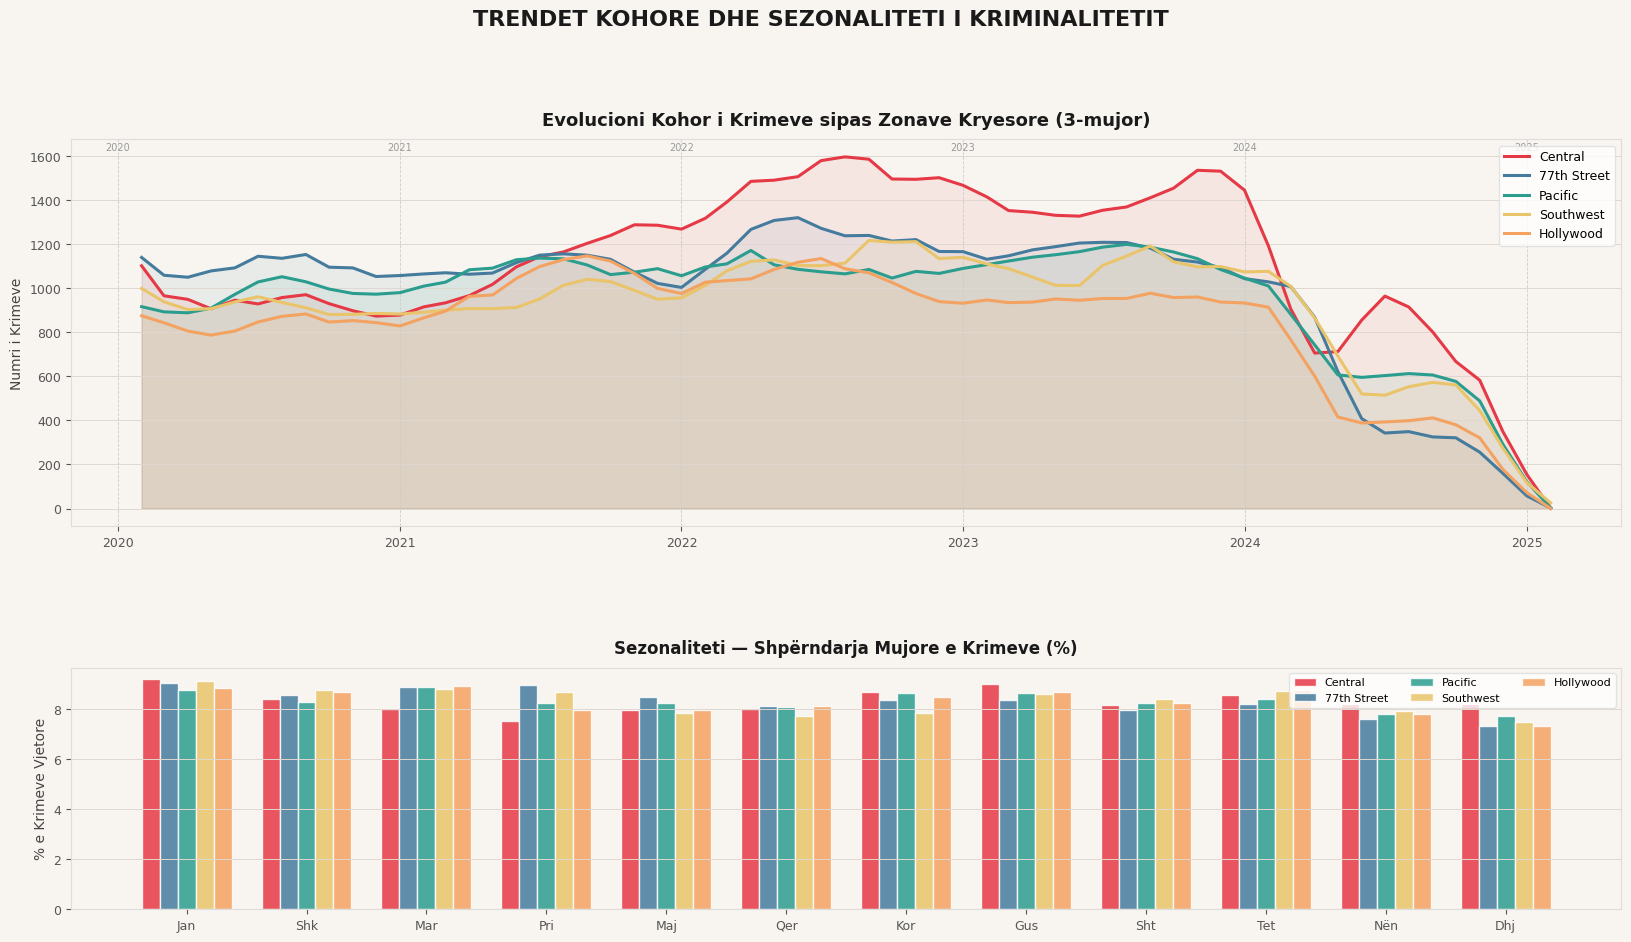

✓ Ruajtur: q5_time_series_seasonality.png


In [8]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# -------------------------------------------------------------------
# 1. NGARKO & PASTRO
# -------------------------------------------------------------------
df = pd.read_csv("Crime_Data_Filtered.csv", low_memory=False)

df["DATE OCC"] = pd.to_datetime(df["DATE OCC"], errors="coerce")
df = df.dropna(subset=["DATE OCC", "AREA NAME"])
df["YearMonth"] = df["DATE OCC"].dt.to_period("M")
df["Month"] = df["DATE OCC"].dt.month
df["Year"]  = df["DATE OCC"].dt.year
df["Part 1-2"] = pd.to_numeric(df["Part 1-2"], errors="coerce")

# Top 5 zona
top5_areas = df["AREA NAME"].value_counts().head(5).index.tolist()
df5 = df[df["AREA NAME"].isin(top5_areas)].copy()

# -------------------------------------------------------------------
# 2. PIVOT: krime mujore për secilën zonë
# -------------------------------------------------------------------
monthly = (df5.groupby(["YearMonth", "AREA NAME"])
           .size().unstack(fill_value=0))
monthly.index = monthly.index.to_timestamp()
monthly = monthly.sort_index()

# Sezonaliteti: mesatare mujore (0-11)
df5["MonthNum"] = df5["DATE OCC"].dt.month
seasonal = (df5.groupby(["MonthNum", "AREA NAME"])
            .size().unstack(fill_value=0))
seasonal = seasonal.reindex(range(1, 13), fill_value=0)

# -------------------------------------------------------------------
# 3. VIZUALIZIM
# -------------------------------------------------------------------
BG = "#f8f5f0"
fig = plt.figure(figsize=(20, 10), facecolor=BG)
gs = gridspec.GridSpec(2, 1, hspace=0.45, height_ratios=[1.6, 1])

palette = ["#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#f4a261"]
month_names = ["Jan", "Shk", "Mar", "Pri", "Maj", "Qer",
               "Kor", "Gus", "Sht", "Tet", "Nën", "Dhj"]

# --- Panel 1: Time series ---
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor(BG)

for area, color in zip(top5_areas, palette):
    if area in monthly.columns:
        series = monthly[area].rolling(3, center=True).mean()  # smoothing
        ax1.plot(monthly.index, series, color=color, linewidth=2.2,
                 label=area, zorder=3)
        ax1.fill_between(monthly.index, series, alpha=0.08, color=color)

ax1.set_title("Evolucioni Kohor i Krimeve sipas Zonave Kryesore (3-mujor)",
              fontsize=13, fontweight="bold", color="#1a1a1a", pad=10)
ax1.set_ylabel("Numri i Krimeve", fontsize=10, color="#444")
ax1.legend(loc="upper right", fontsize=9, framealpha=0.8,
           facecolor="white", edgecolor="#ddd")
ax1.tick_params(labelsize=9, colors="#555")
ax1.grid(axis="y", color="#e0d8d0", linewidth=0.7)
for spine in ax1.spines.values():
    spine.set_edgecolor("#ddd")

# Shton shënime vjeçare
for year in monthly.index.year.unique():
    first_idx = monthly.index[monthly.index.year == year][0]
    ax1.axvline(first_idx, color="#cccccc", linewidth=0.6, linestyle="--")
    ax1.text(first_idx, ax1.get_ylim()[1] * 0.97, str(year),
             fontsize=7, color="#999", ha="center")

# --- Panel 2: Sezonaliteti (radar/bar) ---
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(BG)

x = np.arange(12)
width = 0.15
for idx, (area, color) in enumerate(zip(top5_areas, palette)):
    if area in seasonal.columns:
        vals = seasonal[area].values
        vals_norm = vals / vals.sum() * 100
        ax2.bar(x + idx * width, vals_norm, width=width,
                color=color, alpha=0.85, label=area, edgecolor="white")

ax2.set_xticks(x + width * 2)
ax2.set_xticklabels(month_names, fontsize=9)
ax2.set_ylabel("% e Krimeve Vjetore", fontsize=10, color="#444")
ax2.set_title("Sezonaliteti — Shpërndarja Mujore e Krimeve (%)",
              fontsize=12, fontweight="bold", color="#1a1a1a", pad=10)
ax2.legend(loc="upper right", fontsize=8, framealpha=0.8,
           facecolor="white", edgecolor="#ddd", ncol=3)
ax2.tick_params(labelsize=9, colors="#555")
ax2.grid(axis="y", color="#e0d8d0", linewidth=0.7)
for spine in ax2.spines.values():
    spine.set_edgecolor("#ddd")

fig.suptitle("TRENDET KOHORE DHE SEZONALITETI I KRIMINALITETIT",
             fontsize=16, fontweight="bold", color="#1a1a1a", y=1.01)

plt.savefig("q5_time_series_seasonality.png", dpi=150, bbox_inches="tight",
            facecolor=BG)
plt.show()
print("✓ Ruajtur: q5_time_series_seasonality.png")

# Q6: Raporti midis orës (TIME OCC) dhe moshës së viktimës (Vict Age), ndarë sipas gjinisë (Vict Sex) dhe llojit të krimit.
Kolonat: TIME OCC, Vict Age, Vict Sex, Crm Cd Desc

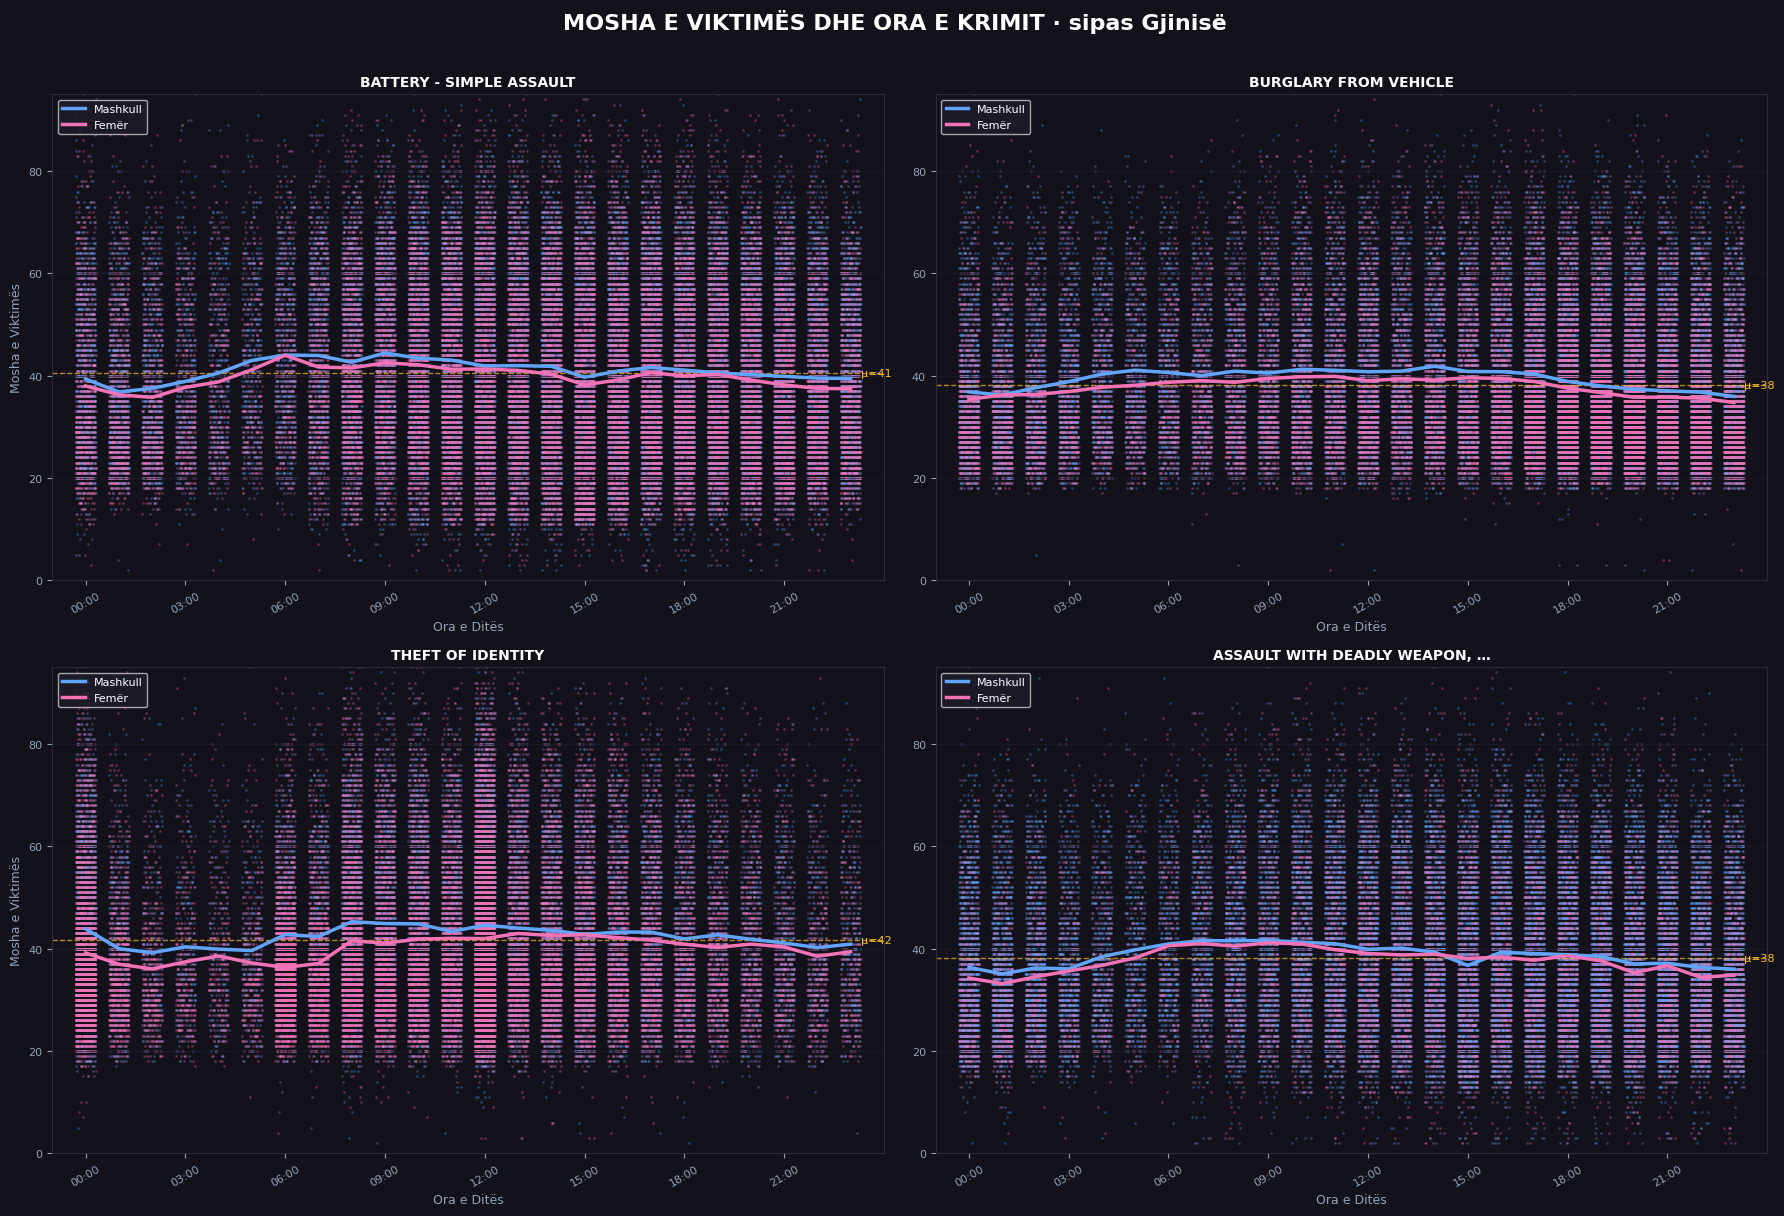

✓ Ruajtur: q6_time_age_sex.png


In [9]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# -------------------------------------------------------------------
# 1. NGARKO & PASTRO
# -------------------------------------------------------------------
df = pd.read_csv("Crime_Data_Filtered.csv", low_memory=False)

df["TIME OCC"] = pd.to_numeric(df["TIME OCC"], errors="coerce")
df["Vict Age"] = pd.to_numeric(df["Vict Age"], errors="coerce")
df = df.dropna(subset=["TIME OCC", "Vict Age", "Vict Sex", "Crm Cd Desc"])
df = df[df["Vict Sex"].isin(["M", "F"])]
df = df[(df["Vict Age"] > 0) & (df["Vict Age"] < 100)]
df["Hour"] = (df["TIME OCC"] // 100).clip(0, 23)

# Top 4 krime
top4 = df["Crm Cd Desc"].value_counts().head(4).index.tolist()
short = {c: c[:28] + ("…" if len(c) > 28 else "") for c in top4}
df4 = df[df["Crm Cd Desc"].isin(top4)].copy()

# -------------------------------------------------------------------
# 2. VIZUALIZIM: 2×2 grid scatter + 2D density
# -------------------------------------------------------------------
BG = "#13111a"
COLOR_M = "#60a5fa"
COLOR_F = "#f472b6"

fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor=BG)
fig.patch.set_facecolor(BG)

for idx, crime in enumerate(top4):
    ax = axes[idx // 2][idx % 2]
    ax.set_facecolor(BG)

    sub = df4[df4["Crm Cd Desc"] == crime]
    sub_m = sub[sub["Vict Sex"] == "M"]
    sub_f = sub[sub["Vict Sex"] == "F"]

    # Scatter me alpha të ulët
    ax.scatter(sub_m["Hour"] + np.random.uniform(-0.3, 0.3, len(sub_m)),
               sub_m["Vict Age"],
               s=1.5, alpha=0.2, color=COLOR_M, rasterized=True)
    ax.scatter(sub_f["Hour"] + np.random.uniform(-0.3, 0.3, len(sub_f)),
               sub_f["Vict Age"],
               s=1.5, alpha=0.2, color=COLOR_F, rasterized=True)

    # Linja mesatare sipas orës
    for data, color, label in [(sub_m, COLOR_M, "Mashkull"),
                                (sub_f, COLOR_F, "Femër")]:
        avg_by_hour = data.groupby("Hour")["Vict Age"].mean()
        ax.plot(avg_by_hour.index, avg_by_hour.values,
                color=color, linewidth=2.5, zorder=5, label=label)

    # Shënon moshën mesatare globale
    avg_all = sub["Vict Age"].mean()
    ax.axhline(avg_all, color="#fbbf24", linewidth=1, linestyle="--", alpha=0.7)
    ax.text(23.3, avg_all, f"μ={avg_all:.0f}", color="#fbbf24",
            va="center", fontsize=8)

    ax.set_title(short[crime], color="white", fontsize=10, fontweight="bold")
    ax.set_xlabel("Ora e Ditës", color="#94a3b8", fontsize=9)
    ax.set_ylabel("Mosha e Viktimës" if idx % 2 == 0 else "",
                  color="#94a3b8", fontsize=9)
    ax.set_xlim(-1, 24)
    ax.set_ylim(0, 95)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 3)],
                       fontsize=7, color="#94a3b8", rotation=30)
    ax.tick_params(labelsize=8, colors="#94a3b8")
    ax.legend(loc="upper left", fontsize=8, facecolor="#1f1d2b",
              labelcolor="white", framealpha=0.8)
    for spine in ax.spines.values():
        spine.set_edgecolor("#2d2b3d")
    ax.grid(axis="y", color="#1f1d2b", linewidth=0.5)

fig.suptitle("MOSHA E VIKTIMËS DHE ORA E KRIMIT · sipas Gjinisë",
             color="white", fontsize=16, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("q6_time_age_sex.png", dpi=150, bbox_inches="tight",
            facecolor=BG)
plt.show()
print("✓ Ruajtur: q6_time_age_sex.png")

# Q7: Llojet e vendndodhjeve (Premis Desc) ku kryhen krimet me armë dhe si ndryshon sipas zonës (AREA NAME).
Kolonat: Premis Desc, Weapon Desc, AREA NAME, LAT, LON

C:\Users\bjorn\AppData\Local\Temp\ipykernel_10284\2918849416.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


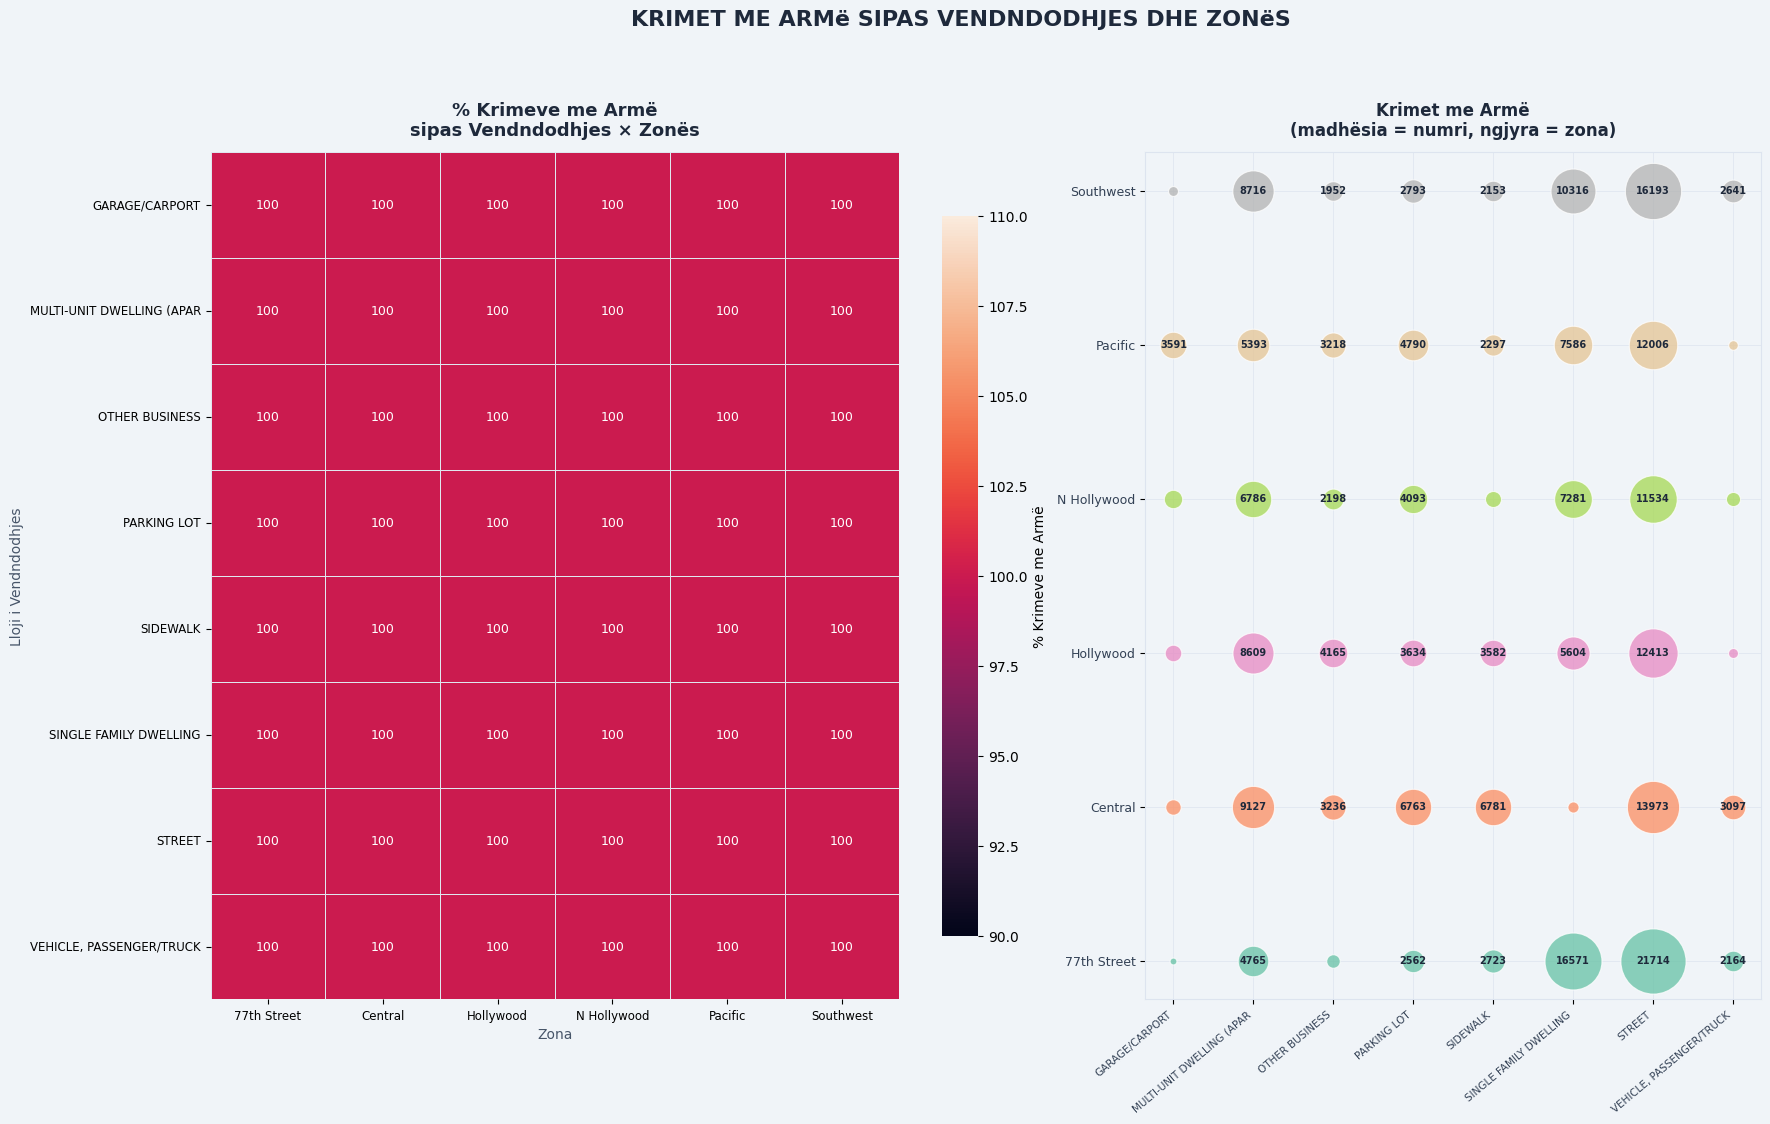

✓ Ruajtur: q7_premises_weapons_area.png


In [10]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import seaborn as sns

# -------------------------------------------------------------------
# 1. NGARKO & PASTRO
# -------------------------------------------------------------------
df = pd.read_csv("Crime_Data_Filtered.csv", low_memory=False)

df = df.dropna(subset=["Premis Desc", "AREA NAME"])
df["Has_Weapon"] = df["Weapon Used Cd"].notna() & (df["Weapon Used Cd"] != "")

# Top 8 premise, top 6 zone
top_premis = df["Premis Desc"].value_counts().head(8).index.tolist()
top_areas  = df["AREA NAME"].value_counts().head(6).index.tolist()

df_f = df[df["Premis Desc"].isin(top_premis) &
          df["AREA NAME"].isin(top_areas)].copy()

df_f["Premis_Short"] = df_f["Premis Desc"].str[:25]
df_f["Area_Short"]   = df_f["AREA NAME"].str[:18]

# -------------------------------------------------------------------
# 2. PIVOT: % krime me armë
# -------------------------------------------------------------------
grouped = df_f.groupby(["Area_Short", "Premis_Short"])
pivot = (grouped["Has_Weapon"].sum() / grouped["Has_Weapon"].count() * 100).unstack(fill_value=0)

# Pivot 2: numri total krimeve
pivot_count = grouped.size().unstack(fill_value=0)

# -------------------------------------------------------------------
# 3. VIZUALIZIM
# -------------------------------------------------------------------
BG = "#f0f4f8"
fig = plt.figure(figsize=(20, 11), facecolor=BG)
gs = gridspec.GridSpec(1, 2, wspace=0.1, width_ratios=[1.4, 1])

# --- Panel majtas: heatmap % armë ---
ax1 = fig.add_subplot(gs[0])
cmap = sns.color_palette("rocket", as_cmap=True)
sns.heatmap(
    pivot.T,
    ax=ax1,
    cmap=cmap,
    annot=True, fmt=".0f",
    linewidths=0.5, linecolor="#e0e7ef",
    cbar_kws={"label": "% Krimeve me Armë", "shrink": 0.85},
    annot_kws={"size": 9}
)
ax1.set_title("% Krimeve me Armë\nsipas Vendndodhjes × Zonës",
              fontsize=13, fontweight="bold", color="#1e293b", pad=12)
ax1.set_xlabel("Zona", fontsize=10, color="#475569")
ax1.set_ylabel("Lloji i Vendndodhjes", fontsize=10, color="#475569")
ax1.tick_params(labelsize=8.5)

# --- Panel djathtas: treemap-style bubble chart ---
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(BG)

# Total krime me armë sipas premise + zone (flat)
flat = (df_f[df_f["Has_Weapon"]].groupby(["Area_Short", "Premis_Short"])
        .size().reset_index(name="count"))

max_count = flat["count"].max()
areas_u = flat["Area_Short"].unique()
premis_u = flat["Premis_Short"].unique()

area_colors = plt.cm.Set2(np.linspace(0, 1, len(areas_u)))
area_color_map = dict(zip(areas_u, area_colors))

for _, row in flat.iterrows():
    x = list(premis_u).index(row["Premis_Short"])
    y = list(areas_u).index(row["Area_Short"])
    size = (row["count"] / max_count) * 2200
    color = area_color_map[row["Area_Short"]]
    ax2.scatter(x, y, s=size, color=color, alpha=0.75, edgecolors="white",
                linewidths=0.8, zorder=3)
    if row["count"] > max_count * 0.08:
        ax2.text(x, y, str(row["count"]), ha="center", va="center",
                 fontsize=7, fontweight="bold", color="#1e293b")

ax2.set_xticks(range(len(premis_u)))
ax2.set_xticklabels(premis_u, rotation=40, ha="right", fontsize=7.5, color="#334155")
ax2.set_yticks(range(len(areas_u)))
ax2.set_yticklabels(areas_u, fontsize=9, color="#334155")
ax2.set_title("Krimet me Armë\n(madhësia = numri, ngjyra = zona)",
              fontsize=12, fontweight="bold", color="#1e293b", pad=12)
ax2.grid(True, color="#dde4ef", linewidth=0.5, zorder=0)
for spine in ax2.spines.values():
    spine.set_edgecolor("#dde4ef")

fig.suptitle("KRIMET ME ARMë SIPAS VENDNDODHJES DHE ZONëS",
             fontsize=16, fontweight="bold", color="#1e293b", y=1.01)

plt.tight_layout()
plt.savefig("q7_premises_weapons_area.png", dpi=150, bbox_inches="tight",
            facecolor=BG)
plt.show()
print("✓ Ruajtur: q7_premises_weapons_area.png")

# Q8: Vonesa midis DATE OCC dhe Date Rptd sipas llojit të krimit dhe zonës, dhe ndikimi i saj në shkallën e zgjidhjes (Status Desc).
Kolonat: DATE OCC, Date Rptd, Crm Cd Desc, AREA NAME, Status Desc

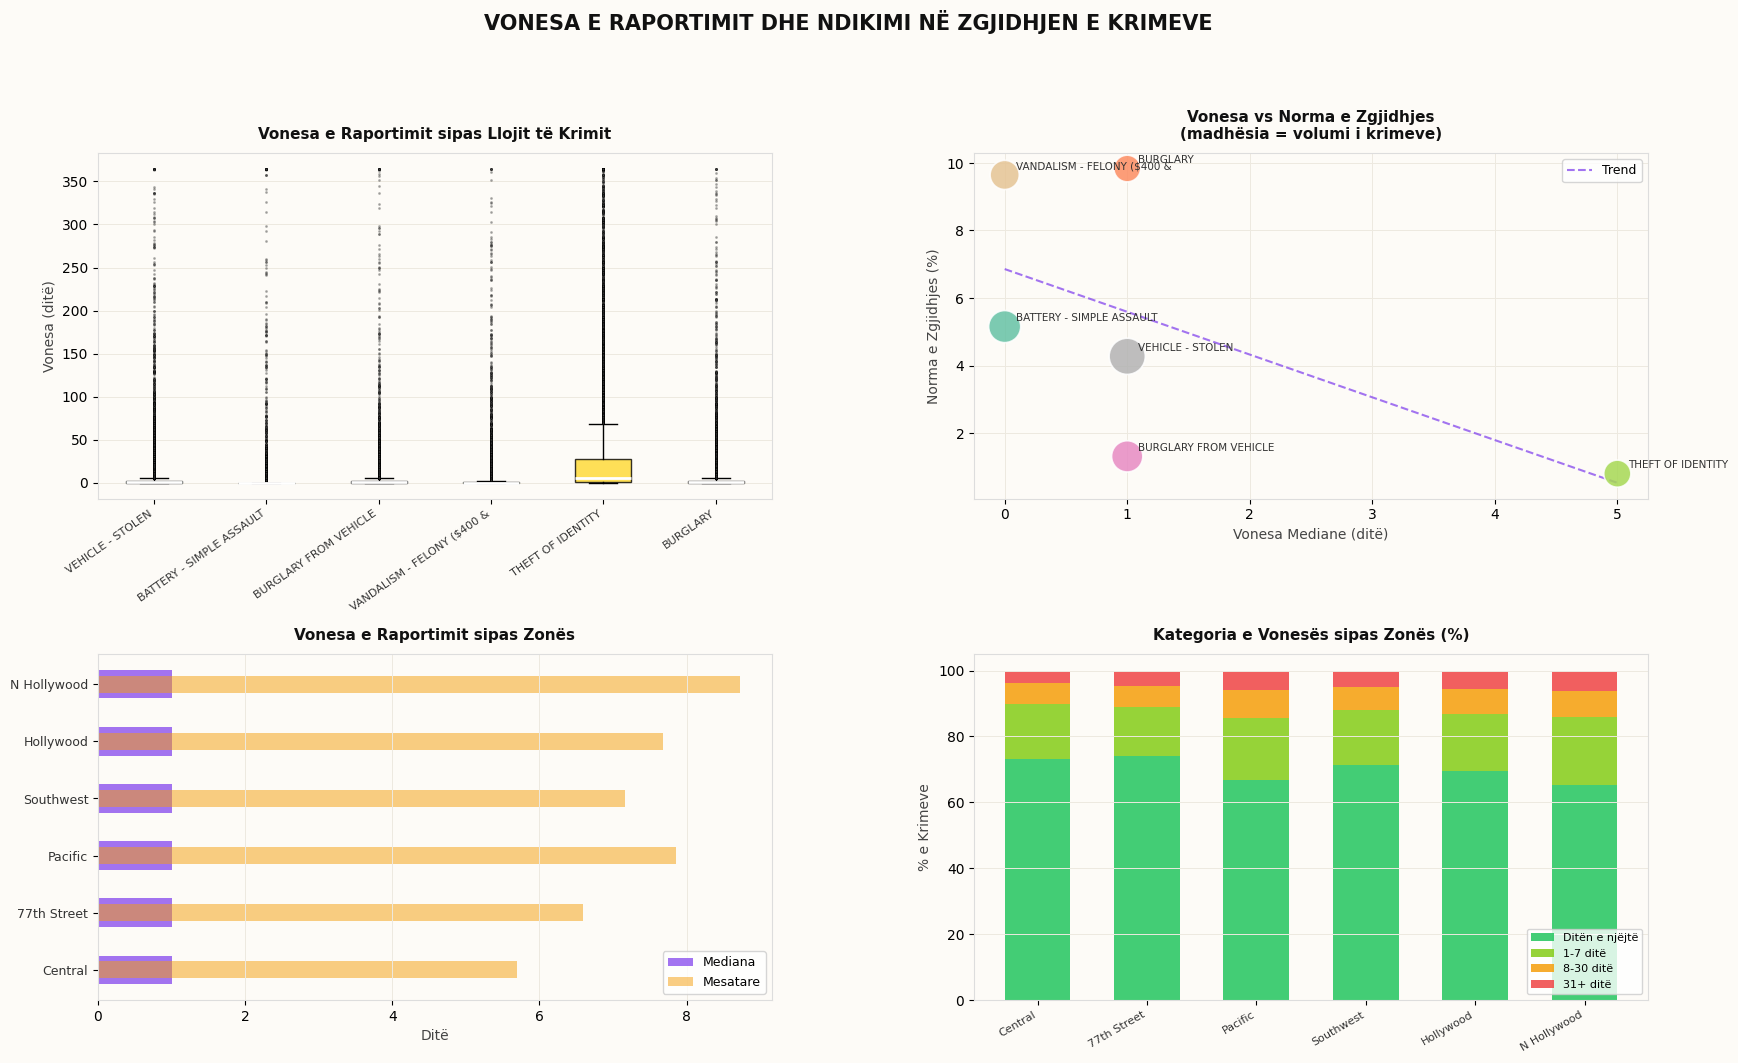

✓ Ruajtur: q8_reporting_delay_resolution.png


In [11]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# -------------------------------------------------------------------
# 1. NGARKO & PASTRO
# -------------------------------------------------------------------
df = pd.read_csv("Crime_Data_Filtered.csv", low_memory=False)

df["DATE OCC"]  = pd.to_datetime(df["DATE OCC"],  errors="coerce")
df["Date Rptd"] = pd.to_datetime(df["Date Rptd"], errors="coerce")
df = df.dropna(subset=["DATE OCC", "Date Rptd", "Crm Cd Desc",
                        "AREA NAME", "Status Desc"])

df["Delay_Days"] = (df["Date Rptd"] - df["DATE OCC"]).dt.days
df = df[(df["Delay_Days"] >= 0) & (df["Delay_Days"] <= 365)]

# Statusi i thjeshtëzuar
df["Solved"] = df["Status Desc"].str.upper().str.contains(
    "ARREST|JUVEN", na=False).astype(int)

# Top 6 krime, top 6 zone
top_crimes = df["Crm Cd Desc"].value_counts().head(6).index.tolist()
top_areas  = df["AREA NAME"].value_counts().head(6).index.tolist()
df_f = df[df["Crm Cd Desc"].isin(top_crimes) &
          df["AREA NAME"].isin(top_areas)].copy()
df_f["Crime_Short"] = df_f["Crm Cd Desc"].str[:26]

# -------------------------------------------------------------------
# 2. VIZUALIZIM
# -------------------------------------------------------------------
BG = "#fdfbf7"
ACCENT = "#7c3aed"

fig = plt.figure(figsize=(20, 11), facecolor=BG)
gs = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.3,
                       height_ratios=[1, 1])

palette = plt.cm.Set2(np.linspace(0, 0.85, 6))

# --- Panel 1: Box plot vonesa sipas krimit ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(BG)

crime_shorts = [c[:26] for c in top_crimes]
data_boxes = [df_f[df_f["Crm Cd Desc"] == c]["Delay_Days"].values
              for c in top_crimes]

bp = ax1.boxplot(data_boxes, patch_artist=True, vert=True,
                 medianprops={"color": "white", "linewidth": 2},
                 flierprops={"marker": ".", "markersize": 2,
                             "alpha": 0.3, "markerfacecolor": "#999"})
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax1.set_xticks(range(1, len(crime_shorts) + 1))
ax1.set_xticklabels(crime_shorts, rotation=35, ha="right",
                    fontsize=8, color="#333")
ax1.set_ylabel("Vonesa (ditë)", fontsize=10, color="#444")
ax1.set_title("Vonesa e Raportimit sipas Llojit të Krimit",
              fontsize=11, fontweight="bold", color="#111", pad=10)
ax1.grid(axis="y", color="#ede9e0", linewidth=0.7)
for spine in ax1.spines.values():
    spine.set_edgecolor("#ddd")

# --- Panel 2: Scatter vonesa vs norma zgjidhjes ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(BG)

summary = (df_f.groupby("Crime_Short")
           .agg(avg_delay=("Delay_Days", "median"),
                solve_rate=("Solved", "mean"),
                count=("Solved", "count"))
           .reset_index())

sizes = (summary["count"] / summary["count"].max()) * 600 + 80
sc = ax2.scatter(summary["avg_delay"], summary["solve_rate"] * 100,
                 s=sizes, c=range(len(summary)),
                 cmap="Set2", alpha=0.85, edgecolors="white", linewidths=1.2,
                 zorder=3)

for _, row in summary.iterrows():
    ax2.annotate(row["Crime_Short"],
                 (row["avg_delay"], row["solve_rate"] * 100),
                 textcoords="offset points", xytext=(8, 4),
                 fontsize=7.5, color="#333")

# Trend line
if len(summary) > 2:
    z = np.polyfit(summary["avg_delay"], summary["solve_rate"] * 100, 1)
    p = np.poly1d(z)
    xs = np.linspace(summary["avg_delay"].min(), summary["avg_delay"].max(), 100)
    ax2.plot(xs, p(xs), "--", color=ACCENT, linewidth=1.5,
             alpha=0.7, label="Trend")
    ax2.legend(fontsize=9)

ax2.set_xlabel("Vonesa Mediane (ditë)", fontsize=10, color="#444")
ax2.set_ylabel("Norma e Zgjidhjes (%)", fontsize=10, color="#444")
ax2.set_title("Vonesa vs Norma e Zgjidhjes\n(madhësia = volumi i krimeve)",
              fontsize=11, fontweight="bold", color="#111", pad=10)
ax2.grid(color="#ede9e0", linewidth=0.7)
for spine in ax2.spines.values():
    spine.set_edgecolor("#ddd")

# --- Panel 3: Vonesa mesatare sipas zonës ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(BG)

area_delay = (df_f.groupby("AREA NAME")["Delay_Days"]
              .agg(["median", "mean"])
              .loc[top_areas]
              .sort_values("median", ascending=True))

y = range(len(area_delay))
ax3.barh(list(y), area_delay["median"].values,
         color=ACCENT, alpha=0.7, label="Mediana", height=0.5)
ax3.barh(list(y), area_delay["mean"].values,
         color="#f59e0b", alpha=0.5, label="Mesatare", height=0.3)
ax3.set_yticks(list(y))
ax3.set_yticklabels(area_delay.index, fontsize=9, color="#333")
ax3.set_xlabel("Ditë", fontsize=10, color="#444")
ax3.set_title("Vonesa e Raportimit sipas Zonës",
              fontsize=11, fontweight="bold", color="#111", pad=10)
ax3.legend(fontsize=9)
ax3.grid(axis="x", color="#ede9e0", linewidth=0.7)
for spine in ax3.spines.values():
    spine.set_edgecolor("#ddd")

# --- Panel 4: Shpërndarja e vonesës (0/1-7/8-30/31+) ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(BG)

bins = [0, 1, 7, 30, 365]
labels_bin = ["Ditën e njëjtë", "1-7 ditë", "8-30 ditë", "31+ ditë"]
df_f["Delay_Cat"] = pd.cut(df_f["Delay_Days"], bins=bins,
                            labels=labels_bin, include_lowest=True)

pivot_cat = (df_f.groupby(["AREA NAME", "Delay_Cat"])
             .size().unstack(fill_value=0))
pivot_cat = pivot_cat.loc[top_areas]
pivot_pct = pivot_cat.div(pivot_cat.sum(axis=1), axis=0) * 100

colors_cat = ["#22c55e", "#84cc16", "#f59e0b", "#ef4444"]
bottom = np.zeros(len(pivot_pct))
for cat, color in zip(labels_bin, colors_cat):
    if cat in pivot_pct.columns:
        vals = pivot_pct[cat].values
        ax4.bar(range(len(top_areas)), vals, bottom=bottom,
                color=color, alpha=0.85, label=cat, width=0.6)
        bottom += vals

ax4.set_xticks(range(len(top_areas)))
ax4.set_xticklabels([a[:15] for a in top_areas], rotation=30,
                    ha="right", fontsize=8, color="#333")
ax4.set_ylabel("% e Krimeve", fontsize=10, color="#444")
ax4.set_title("Kategoria e Vonesës sipas Zonës (%)",
              fontsize=11, fontweight="bold", color="#111", pad=10)
ax4.legend(fontsize=8, loc="lower right", framealpha=0.8)
ax4.grid(axis="y", color="#ede9e0", linewidth=0.7)
for spine in ax4.spines.values():
    spine.set_edgecolor("#ddd")

fig.suptitle("VONESA E RAPORTIMIT DHE NDIKIMI NË ZGJIDHJEN E KRIMEVE",
             fontsize=15, fontweight="bold", color="#111", y=1.01)

plt.savefig("q8_reporting_delay_resolution.png", dpi=150, bbox_inches="tight",
            facecolor=BG)
plt.show()
print("✓ Ruajtur: q8_reporting_delay_resolution.png")